# 다중클래스분류_callback사용해_과적합_막고_최고성능모델_저장하기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv('./data/winequality-white.csv', sep=';')
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


<Axes: >

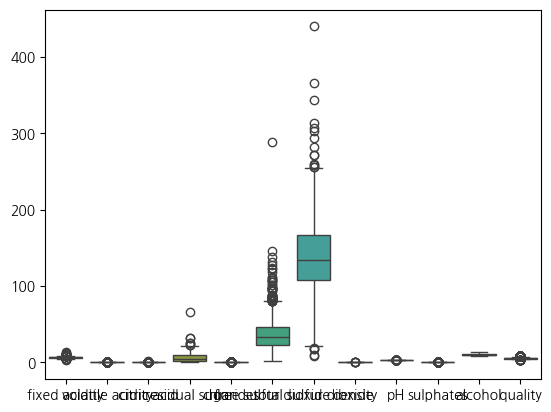

In [3]:
# 이상치가 많으므로 RobustScaler를 써야겠다고 생각하기
sns.boxplot(data)

In [5]:
data['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [7]:
X = data.drop('quality', axis=1)
y = data['quality']

In [8]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [9]:
# one-hot 인코딩
y = pd.get_dummies(y)
y

,3,4,5,6,7,8,9
0,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False
3,False,False,False,True,False,False,False
4,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
4893,False,False,False,True,False,False,False
4894,False,False,True,False,False,False,False
4895,False,False,False,True,False,False,False
4896,False,False,False,False,True,False,False


In [10]:

data['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [12]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

In [13]:
rs = RobustScaler()
train_temp = rs.fit_transform(X_train)
valid_temp = rs.transform(X_valid)
test_temp = rs.transform(X_test)

rs_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index = X_train.index)
rs_X_valid = pd.DataFrame(valid_temp, columns=X_valid.columns, index = X_valid.index)
rs_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index = X_test.index)

In [14]:
rs_X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
3940,0.090909,1.272727,0.416667,0.451220,0.714286,0.090909,0.216667,0.507205,-0.05,0.142857,-0.578947
3905,-0.272727,0.636364,-0.166667,-0.170732,-0.500000,0.000000,-0.783333,-0.811527,0.40,1.071429,1.105263
53,-0.363636,-0.727273,0.250000,-0.512195,0.142857,0.227273,-0.450000,-0.622478,0.70,-0.928571,0.263158
2576,-0.272727,0.090909,0.666667,0.585366,-0.285714,1.818182,1.533333,0.465706,0.05,0.142857,-0.526316
1970,1.363636,2.090909,0.916667,-0.329268,-0.500000,-0.090909,-0.316667,0.138329,0.30,-0.071429,0.157895
...,...,...,...,...,...,...,...,...,...,...,...
2609,0.272727,-0.545455,-0.166667,-0.524390,-1.714286,-1.363636,-1.783333,-1.035159,0.15,-0.857143,0.842105
2530,-0.909091,0.363636,-1.666667,-0.439024,-0.500000,1.045455,0.466667,-0.325072,1.05,0.785714,0.052632
1231,1.000000,1.363636,0.416667,-0.085366,-0.928571,0.272727,-0.350000,-0.414986,0.00,0.428571,1.052632
3948,-1.000000,-1.090909,-0.166667,0.024390,0.142857,-0.363636,-0.500000,0.205187,0.75,-0.214286,-0.578947


In [15]:
y_train.shape

(2938, 7)

# 모델을 최고 성능에서 저장하고 중지하기

In [17]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [18]:
data['quality'].nunique()

7

In [20]:
n_class = y_train.shape[1]
model = Sequential()
model.add(Input(shape=(rs_X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(n_class, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,495 (13.65 KB)

 Trainable params: 3,495 (13.65 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
import os

Epoch 1/1000


I0000 00:00:1747337695.322773   99664 service.cc:152] XLA service 0x7fc394005330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747337695.322810   99664 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-16 04:34:55.340269: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747337695.456307   99664 cuda_dnn.cc:529] Loaded cuDNN version 90300


58/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2758 - loss: 1.7702

I0000 00:00:1747337696.767701   99664 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.3069 - loss: 1.6803 - val_accuracy: 0.4959 - val_loss: 1.2574
Epoch 2/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4879 - loss: 1.2561 - val_accuracy: 0.5367 - val_loss: 1.1817
Epoch 3/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5345 - loss: 1.1262 - val_accuracy: 0.5378 - val_loss: 1.1445
Epoch 4/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5378 - loss: 1.1161 - val_accuracy: 0.5408 - val_loss: 1.1163
Epoch 5/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5542 - loss: 1.0732 - val_accuracy: 0.5418 - val_loss: 1.1039
Epoch 6/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5570 - loss: 1.0711 - val_accuracy: 0.5459 - val_loss: 1.1018
Epoch 7/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5617 - loss: 1.0265 - val_accuracy: 0.5735 - val_loss: 1.0897
Epoch 8/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5669 - loss: 1.0230 - val_accuracy: 0.5694 - val_l

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6688 - loss: 0.7990 - val_accuracy: 0.5673 - val_loss: 1.0871
Epoch 52/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6605 - loss: 0.7971 - val_accuracy: 0.5816 - val_loss: 1.0816
Epoch 53/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6778 - loss: 0.7699 - val_accuracy: 0.5643 - val_loss: 1.0918
Epoch 54/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6771 - loss: 0.8048 - val_accuracy: 0.5684 - val_loss: 1.0947
Epoch 55/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6699 - loss: 0.7939 - val_accuracy: 0.5745 - val_loss: 1.0972
Epoch 56/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6819 - loss: 0.7702 - val_accuracy: 0.5582 - val_loss: 1.0796
Epoch 57/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6779 - loss: 0.7847 - val_accuracy: 0.5776 - val_loss: 1.1031
Epoch 58/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6848 - loss: 0.7719 - val_accuracy: 0.5663 -

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7370 - loss: 0.6439 - val_accuracy: 0.5827 - val_loss: 1.2301
Epoch 102/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7615 - loss: 0.6183 - val_accuracy: 0.5704 - val_loss: 1.2322
Epoch 103/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 0.6322 - val_accuracy: 0.5571 - val_loss: 1.2362
Epoch 104/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7667 - loss: 0.5983 - val_accuracy: 0.5602 - val_loss: 1.2467
Epoch 105/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7556 - loss: 0.6419 - val_accuracy: 0.5551 - val_loss: 1.2482
Epoch 106/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7358 - loss: 0.6366 - val_accuracy: 0.5633 - val_loss: 1.2523
Epoch 107/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7479 - loss: 0.6418 - val_accuracy: 0.5612 - val_loss: 1.2586
Epoch 108/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7439 - loss: 0.6260 - val_accuracy: 0

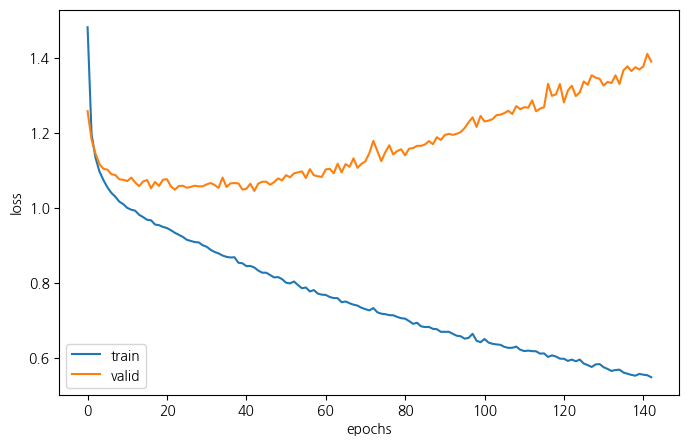

In [22]:
# 분류분석이니 정확도
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(patience=100)
os.makedirs("./model", exist_ok=True) # 디렉토리 자동 생성
filepath = "./model/witewine_loss_{val_loss:.4f}_epoch_{epoch:04d}__.keras"
model_save = ModelCheckpoint(filepath=filepath, save_best_only=True)
history = model.fit(rs_X_train, y_train,
                   epochs=1000,
                   batch_size=32,
                   validation_data=(rs_X_valid, y_valid),
                   callbacks=[early_stop, model_save])

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()




In [23]:
data['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

# 데이터 증폭 후 분석
* 데이터 증폭 + 스케일러 사용 시
* 데이터 증폭 후 스케일러로 스케일링

In [24]:
from imblearn.over_sampling import SMOTE

In [25]:
X = data.drop('quality', axis=1)
y = data['quality']

In [26]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

In [27]:
print(y_train.nunique())
print(y_valid.nunique())
print(y_test.nunique())

7
7
7


In [28]:
smt = SMOTE(k_neighbors=2, random_state=42)
smt_X_train, smt_y_train = smt.fit_resample(X_train, y_train)
smt_X_train = pd.DataFrame(smt_X_train, columns=X_train.columns)
smt_y_train = pd.Series(smt_y_train)

/home/ricky/miniforge3/envs/tf/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [58]:
smt_y_train.value_counts()

quality
7    1318
5    1318
6    1318
4    1318
8    1318
3    1318
9    1318
Name: count, dtype: int64

In [29]:
rs = RobustScaler()

train_temp = rs.fit_transform(smt_X_train)
valid_temp = rs.transform(X_valid)
test_temp = rs.transform(X_test)

rs_X_train = pd.DataFrame(train_temp, columns=smt_X_train.columns)
rs_X_valid = pd.DataFrame(valid_temp, columns=X_valid.columns, index = X_valid.index)
rs_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index = X_test.index)

In [30]:
ot_smt_y_train = pd.get_dummies(smt_y_train)
ot_smt_y_train

,3,4,5,6,7,8,9
0,False,False,False,False,True,False,False
1,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False
4,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...
9221,False,False,False,False,False,False,True
9222,False,False,False,False,False,False,True
9223,False,False,False,False,False,False,True
9224,False,False,False,False,False,False,True


In [31]:
y_valid = pd.get_dummies(y_valid)
y_valid

,3,4,5,6,7,8,9
2794,False,False,True,False,False,False,False
2860,False,False,False,True,False,False,False
4885,False,False,False,True,False,False,False
2062,False,False,True,False,False,False,False
176,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...
2985,False,False,False,False,True,False,False
4778,False,False,False,True,False,False,False
3841,False,False,False,True,False,False,False
3937,False,False,True,False,False,False,False


In [32]:
y_test = pd.get_dummies(y_test)
y_test        

,3,4,5,6,7,8,9
2613,False,False,True,False,False,False,False
2361,False,False,True,False,False,False,False
4245,False,False,True,False,False,False,False
3947,False,False,False,False,True,False,False
3799,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...
4502,False,False,False,True,False,False,False
3148,False,False,False,True,False,False,False
1562,False,False,False,False,True,False,False
37,False,False,False,True,False,False,False


In [33]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint

n_class = ot_smt_y_train.shape[1]
model = Sequential()
model.add(Input(shape=(smt_X_train.shape[1], )))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(n_class, activation='softmax'))  # 븐류클래스가 7개이기 때문 (3~9)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,495 (13.65 KB)

 Trainable params: 3,495 (13.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3552 - loss: 1.6292 - val_accuracy: 0.3673 - val_loss: 1.4546
Epoch 2/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6340 - loss: 0.9332 - val_accuracy: 0.3827 - val_loss: 1.3795
Epoch 3/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6742 - loss: 0.8002 - val_accuracy: 0.3898 - val_loss: 1.3646
Epoch 4/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6955 - loss: 0.7626 - val_accuracy: 0.4082 - val_loss: 1.3113
Epoch 5/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7099 - loss: 0.7084 - val_accuracy: 0.4469 - val_loss: 1.2799
Epoch 6/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7289 - loss: 0.6742 - val_accuracy: 0.4327 - val_loss: 1.2911
Epoch 7/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7335 - loss: 0.6545 - val_accuracy: 0.4653 - val_loss: 1.2921
Epoch 8/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7488 - loss: 0.6369 -

289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8635 - loss: 0.3245 - val_accuracy: 0.5112 - val_loss: 1.6930
Epoch 51/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8697 - loss: 0.3226 - val_accuracy: 0.5082 - val_loss: 1.6483
Epoch 52/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8682 - loss: 0.3132 - val_accuracy: 0.5010 - val_loss: 1.7271
Epoch 53/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8732 - loss: 0.3130 - val_accuracy: 0.5031 - val_loss: 1.6595
Epoch 54/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8752 - loss: 0.3082 - val_accuracy: 0.5296 - val_loss: 1.6262
Epoch 55/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8746 - loss: 0.3120 - val_accuracy: 0.5235 - val_loss: 1.6585
Epoch 56/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8745 - loss: 0.3122 - val_accuracy: 0.5347 - val_loss: 1.6436
Epoch 57/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8859 - loss: 0.2921 - val_ac

289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9043 - loss: 0.2349 - val_accuracy: 0.5469 - val_loss: 2.0415
Epoch 100/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9046 - loss: 0.2373 - val_accuracy: 0.5337 - val_loss: 2.0600
Epoch 101/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9113 - loss: 0.2237 - val_accuracy: 0.5010 - val_loss: 2.1460
Epoch 102/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9041 - loss: 0.2380 - val_accuracy: 0.5357 - val_loss: 2.1029
Epoch 103/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9072 - loss: 0.2271 - val_accuracy: 0.5520 - val_loss: 2.0938
Epoch 104/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9050 - loss: 0.2429 - val_accuracy: 0.4990 - val_loss: 2.1538
Epoch 105/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8975 - loss: 0.2593 - val_accuracy: 0.5214 - val_loss: 2.1769
Epoch 106/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9079 - loss: 0.2317 -

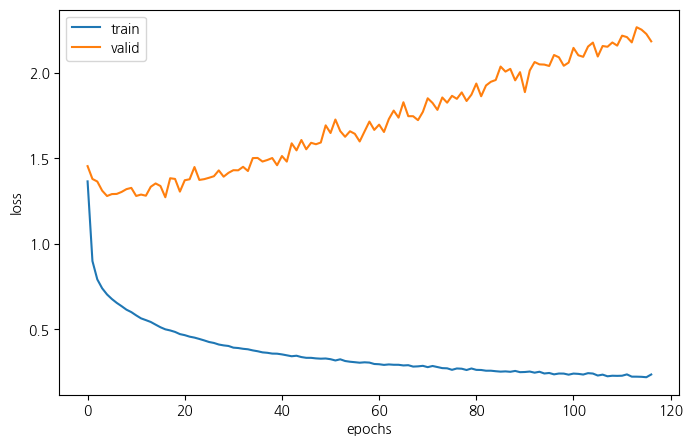

In [34]:
import os

# 분류분석이니 정확도
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(patience=100)
os.makedirs("./model", exist_ok=True) # 디렉토리 자동 생성
filepath = "./model/witewine_loss_{val_loss:.4f}_epoch_{epoch:04d}__.keras"
model_save = ModelCheckpoint(filepath=filepath, save_best_only=True)
history = model.fit(rs_X_train, ot_smt_y_train,
                   epochs=1000,
                   batch_size=32,
                   validation_data=(rs_X_valid, y_valid),
                   callbacks=[early_stop, model_save])

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()


# 저장된 best모델 불러와서 사용하기

In [71]:
rs_X_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
2613,-0.337800,0.772063,1.752696,1.045876,0.617084,-0.051244,0.242181,0.706733,-0.681818,-0.551977,-0.616379
2361,1.345167,-0.289524,1.208226,0.033782,0.617084,-0.819912,-0.386251,0.492741,0.272727,0.867392,-0.497429
4245,0.714054,0.675555,1.298971,1.555908,-0.136666,0.614934,-0.154723,1.105910,-0.818182,0.236561,-0.695680
3947,-0.863728,0.193016,-0.062203,-0.213265,0.153238,0.563689,0.275256,-0.684214,0.409091,-0.236561,0.692077
3799,0.082941,0.193016,-0.425183,-0.213265,0.153238,-0.461200,0.854075,-0.243885,-0.090909,0.788538,0.176625
...,...,...,...,...,...,...,...,...,...,...,...
4502,0.188127,-0.289524,-0.152948,-0.197326,0.617084,0.102489,0.506784,-0.297383,-0.363636,0.315415,0.176625
3148,-0.758542,-0.482539,0.300776,2.177509,-0.020704,0.358711,0.076804,1.361054,0.045455,-0.315415,-0.854281
1562,0.188127,0.579047,1.480461,-0.324834,-0.716474,-0.204978,0.010653,-0.585448,0.363636,-1.103953,0.493826
37,0.082941,0.482539,-0.062203,-0.372650,0.791027,0.409956,0.209106,-0.461992,-0.409091,-1.498222,0.097324


In [36]:
from keras.models import load_model

In [37]:
best_model = load_model('./model/whitewine_loss_1.0439_epoch_0019.keras')
wine_pred = best_model.predict(rs_X_test)
wine_pred = pd.DataFrame(wine_pred, columns=y_test.columns)
wine_pred

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


,3,4,5,6,7,8,9
0,0.001514,0.022111,0.654443,0.315449,0.005456,0.000988,0.000039
1,0.008809,0.064304,0.628742,0.278540,0.018334,0.001080,0.000191
2,0.000615,0.008951,0.689063,0.284263,0.015801,0.001286,0.000021
3,0.001166,0.005522,0.032532,0.370770,0.437864,0.148276,0.003870
4,0.006402,0.011558,0.308861,0.590326,0.073753,0.008414,0.000685
...,...,...,...,...,...,...,...
975,0.004080,0.010272,0.212741,0.580111,0.169916,0.021792,0.001087
976,0.000155,0.002772,0.401183,0.559645,0.030327,0.005892,0.000025
977,0.002437,0.011319,0.042569,0.410742,0.405793,0.121124,0.006016
978,0.002720,0.013698,0.326840,0.639070,0.014767,0.002772,0.000134


In [38]:
best_model.evaluate(rs_X_test, y_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5767 - loss: 1.0695


[1.0522127151489258, 0.5602040886878967]